In [1]:
import os
import urllib.request

with open("C:\\Users\\shash\\Code\\Training_LLM\\archive\\the-verdict.txt", "r") as file:
    text_data = file.read()

In [2]:
print(text_data[:500])  # Print the first 500 characters to verify the content

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)

"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it'


In [3]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(f"Number of Characters in the text: {len(text_data)}")
print(f"Number of Tokens in the text: {len(tokenizer.encode(text_data))}")

Number of Characters in the text: 20479
Number of Tokens in the text: 5145


In [4]:
from torch.utils.data import Dataset, DataLoader
import torch
class GPTDataset(Dataset):
    def __init__(self, text, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, index):
        return self.input_ids[index], self.target_ids[index]
    

def create_dataloader(text, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    dataset = GPTDataset(text, tokenizer, max_length, stride)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)
    return dataloader

In [5]:
### Training Configuration ###
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12, 
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [6]:
train_ratio = 0.90
split_index = int(len(text_data) * train_ratio)
train_text = text_data[:split_index]
val_text = text_data[split_index:]

torch.manual_seed(123)

train_loader = create_dataloader(
    train_text,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)


val_loader = create_dataloader(
    val_text,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [7]:
# ### Basic Sanity Check ###
# if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
#     print("Warning: The training dataset is too small for the specified context length. Consider reducing the context length or increasing the dataset size.")

# if total_tokens * (1 - train_ratio) < GPT_CONFIG_124M["context_length"]:
#     print("Warning: The validation dataset is too small for the specified context length. Consider reducing the context length or increasing the dataset size.")

In [8]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

print("Sample Batch from Training Loader:")
for x, y in train_loader:
    print("Input IDs Shape:", x.shape)
    print("Target IDs Shape:", y.shape)
    break

print("Sample Batch from Validation Loader:")
for x, y in val_loader:
    print("Input IDs Shape:", x.shape)
    print("Target IDs Shape:", y.shape)
    break


Number of training batches: 9
Number of validation batches: 1
Sample Batch from Training Loader:
Input IDs Shape: torch.Size([2, 256])
Target IDs Shape: torch.Size([2, 256])
Sample Batch from Validation Loader:
Input IDs Shape: torch.Size([2, 256])
Target IDs Shape: torch.Size([2, 256])


In [9]:
from model import GPTModel
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (position_embedding): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_block): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
       

In [10]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_loader(dataloader, model, device, num_batches=None):
    total_loss = 0.0
    if len(dataloader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(dataloader)
    else:
        num_batches = min(num_batches, len(dataloader))
    
    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i >= num_batches:
            break
        batch_loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += batch_loss.item()
    return total_loss / num_batches

In [11]:
%%time
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

CPU times: total: 1min 19s
Wall time: 22.3 s


In [12]:
print(f"Initial Training Loss: {train_loss:.4f}")
print(f"Initial Validation Loss: {val_loss:.4f}")

Initial Training Loss: 10.9751
Initial Validation Loss: 10.9701


In [13]:
## Few Helper Functions for Training Loop ##
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    token_ids_list = token_ids.squeeze(0).tolist()
    text = tokenizer.decode(token_ids_list)
    return text

def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probs = torch.nn.functional.softmax(logits, dim=-1)
        idx_next = torch.argmax(probs, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

## Pre-Training Loop

In [14]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):

    train_losses, val_losses, track_token_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_token_seen.append(tokens_seen)
                print(f"Epoch {epoch+1}/{num_epochs}, Step {global_step:06d}, Tokens Seen: {tokens_seen}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_token_seen




def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)

    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.position_embedding.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model, idx=encoded, max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(f"Sample Generated Text:\n{decoded_text}\n")
    model.train()


In [15]:
import time
start_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-1)
num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, 
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
print(f"Total Training Time: {(end_time - start_time) / 60:.2f} minutes")


Epoch 1/10, Step 000000, Tokens Seen: 512, Train Loss: 10.4900, Val Loss: 10.5119
Epoch 1/10, Step 000005, Tokens Seen: 3072, Train Loss: 9.2493, Val Loss: 9.4181
Sample Generated Text:
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

Epoch 2/10, Step 000010, Tokens Seen: 5632, Train Loss: 8.7279, Val Loss: 8.9398
Epoch 2/10, Step 000015, Tokens Seen: 8192, Train Loss: 8.1778, Val Loss: 8.4720
Sample Generated Text:
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

Epoch 3/10, Step 000020, Tokens Seen: 10752, Train Loss: 7.6158, Val Loss: 7.9916
Epoch 3/10, Step 000025, Tokens Seen: 13312, Train Loss: 7.1680, Val Loss: 7.6086
Sample Generated Text:
Every effort moves you, the, the, the, the, the,, the, the, the, the,,, the,, the, the, the, the, the, the, the, the, the, the, the, the, the

Epoch 4/10, Step 000030, Tokens Seen: 15872, Train Loss: 6.7109, Val Loss: 7.2783
Epoch 4/10, Step 000035, Tokens Seen: 18432, Train Loss: 6.3928, Val 

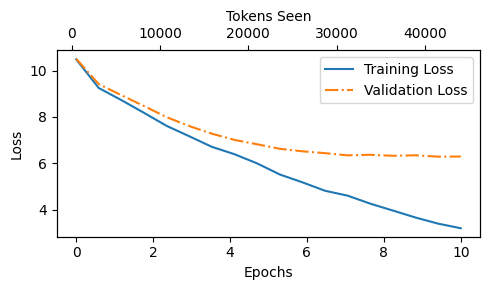

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epoch_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))

    ax1.plot(epoch_seen, train_losses, label="Training Loss")
    ax1.plot(epoch_seen, val_losses, linestyle='-.', label="Validation Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens Seen")

    fig.tight_layout()
    plt.savefig("Loss-Plot.png")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [22]:
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (position_embedding): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_block): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
       

In [23]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8
}

inverse_vocab = {v:k for k,v in vocab.items()}

In [24]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [26]:
probas = torch.softmax(next_token_logits, dim=0)
print("Probability Tensor: ",probas)

next_token_id = torch.argmax(probas).item()
print("Next Token Id: ", next_token_id)

print("Next Token: ", inverse_vocab[next_token_id])

Probability Tensor:  tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
Next Token Id:  3
Next Token:  forward


In [27]:
## Replacing Argmax with Multinomial Function
torch.manual_seed(123)

next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [29]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [30]:
def softmax_with_temprature(logits, temprature):
    scaled_logits = logits / temprature
    return torch.softmax(scaled_logits, dim=0)

tempratures = [1, 0.1, 5]

scaled_probas = [softmax_with_temprature(next_token_logits, t) for t in tempratures]

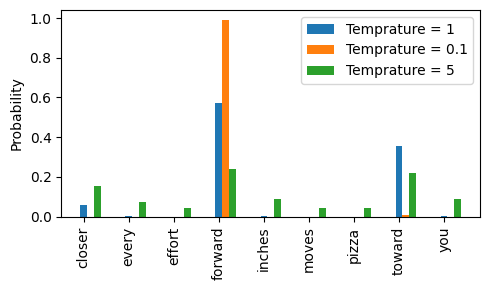

In [31]:
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5,3))
for i, T in enumerate(tempratures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temprature = {T}')

ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temprature-plot.png")
plt.show()

In [32]:
# Top k Sampling
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top Logits: ", top_logits)
print("Top Position: ", top_pos)

Top Logits:  tensor([6.7500, 6.2800, 4.5100])
Top Position:  tensor([3, 7, 0])


In [33]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [34]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


## Merging Temprature and Top K logits (Text Generation)

In [37]:
def generate(model, idx, max_new_tokens, context_size, temprature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        if top_k:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                condition=logits < min_val,
                input=torch.tensor(float("-inf")).to(logits.device),
                other=logits
            )

        if temprature > 0.0:
            logits = logits / temprature
            probas = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probas, num_samples=1)

        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [38]:
## New Decoding 
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temprature=1.4
)

print("Output Text: \n", token_ids_to_text(token_ids, tokenizer))

Output Text: 
 Every effort moves you't," she to. a a. at!
I by his-


In [39]:
## Saving the Model ##
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
    },
    "model_and_optimizer.pth"
)

In [40]:
checkpoint = torch.load("model_and_optimizer.pth")
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (position_embedding): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_block): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
       